# 901: SCI v1.0 vs v1.1 Scenario Database Comparison

Diagnostic comparison between the SCI v1.0-based ("first submission") pipeline run
and the current SCI v1.1-based (this revision) run, to help disentangle how much of
any observed distributional shift is due to:

1. A materially different/larger scenario database between the two SCI releases
   (v1.1 covers more scenarios, and infilling may differ), versus
2. Changes in our own pipeline's methodology (harmonisation/infilling, the MAGICC
   QEXTRA/Kyoto-basket redesign, etc.)

**v1.0 results**: `analysis/output_gaurav/output/` - the original submission's full
pipeline output (already computed against SCI v1.0; not rerun here - see the note
below on why re-running `100_prepare_sci_data.ipynb` against SCI v1.0 wasn't needed).

**v1.1 results**: `OUTPUT_FOLDER` - this revision's full production run.

Compared for both the NZCO2-achieving scenario set and its NZGHG-achieving subset:
- Year of net-zero CO2
- Peak GSAT (ANTHROPOGENIC/`"ALL"` flag - the same total-warming quantity under both
  pipelines' naming conventions - median across ensemble members per scenario)
- GSAT in 2100 (same)
- Cumulative net-negative CO2 emissions by 2100

Both pipelines' relevant output files happen to share the same column schema (the
`500_gsat_metrics_*.csv` per-run_id format, and the `*_netzero_timings_cumnetnegco2.csv`
per-scenario format, predate this session's other restructuring), so no reprocessing
of the raw v1.0 data was necessary - just loading and aligning the two existing
outputs.

In [30]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import dotenv

dotenv.load_dotenv()
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
V1_0_FOLDER = Path("output_gaurav/output")

PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

VERSION_COLORS = {"v1.0": "#999999", "v1.1": "#00aad0"}

## Load net-zero timing + cumulative net-negative CO2 data

Both files already carry `achieve_netzero_ghg` per scenario, so the NZGHG subset is
just a filter on the combined table - no separate file needed for it.

In [31]:
v10_timing = pd.read_csv(V1_0_FOLDER / "105_netzero_timings_cumnetnegco2.csv")
v10_timing["version"] = "v1.0"

v11_timing = pd.read_csv(OUTPUT_FOLDER / "201_netzero_timings_cumnetnegco2.csv")
v11_timing["version"] = "v1.1"

timing_cols = [
    "model", "scenario", "year_netzero_co2", "achieve_netzero_ghg",
    "cumulative_netnegative_co2", "version",
]
timing_df = pd.concat([v10_timing[timing_cols], v11_timing[timing_cols]], ignore_index=True)

for version, df in [("v1.0", v10_timing), ("v1.1", v11_timing)]:
    n_ghg = df["achieve_netzero_ghg"].sum()
    print(f"{version}: {len(df)} NZCO2-achieving scenarios ({n_ghg} also achieve NZGHG, "
          f"{100*n_ghg/len(df):.1f}%)")

v1.0: 743 NZCO2-achieving scenarios (328 also achieve NZGHG, 44.1%)
v1.1: 864 NZCO2-achieving scenarios (388 also achieve NZGHG, 44.9%)


## Load GSAT metrics (peak, 2100)

Restricted to the ANTHROPOGENIC/`"ALL"` total-warming flag, excluding the synthetic
`_NZCO2`/`_NZKyoto` stylised hold-variant rows (not part of this comparison - these
are constructed scenarios, not real database entries), aggregated to one row per
`(model, scenario)` via the median across ensemble members.

In [32]:
def load_gsat_medians(path, flag_value, version_label):
    df = pd.read_csv(path, usecols=["model", "scenario", "magicc_flag", "gsat_peak", "gsat_2100"])
    df = df[df["magicc_flag"] == flag_value]
    df = df[~df["scenario"].str.endswith(("_NZCO2", "_NZKyoto"))]
    med = df.groupby(["model", "scenario"])[["gsat_peak", "gsat_2100"]].median().reset_index()
    med["version"] = version_label
    return med

v10_gsat = load_gsat_medians(V1_0_FOLDER / "500_gsat_metrics_regenerated.csv", "ALL", "v1.0")
v11_gsat = load_gsat_medians(OUTPUT_FOLDER / "500_gsat_metrics_regenerated.csv", "ANTHROPOGENIC", "v1.1")

gsat_df = pd.concat([v10_gsat, v11_gsat], ignore_index=True)
print(f"v1.0: {len(v10_gsat)} scenarios with GSAT metrics")
print(f"v1.1: {len(v11_gsat)} scenarios with GSAT metrics")

v1.0: 685 scenarios with GSAT metrics
v1.1: 784 scenarios with GSAT metrics


In [33]:
combined = timing_df.merge(gsat_df, on=["model", "scenario", "version"], how="inner")
print(f"Combined (timing + GSAT both present): {len(combined)} rows")
combined.groupby("version").size()

Combined (timing + GSAT both present): 1469 rows


version
v1.0    685
v1.1    784
dtype: int64

## Comparison plots

4 metrics x 2 groups (NZCO2 set / NZGHG subset). Histograms use `density=True` (not
raw counts) since v1.0 and v1.1 have different numbers of scenarios - we're comparing
distribution *shape*, not absolute counts, so both the histogram and the KDE overlay
need to be on the same normalized-density scale.

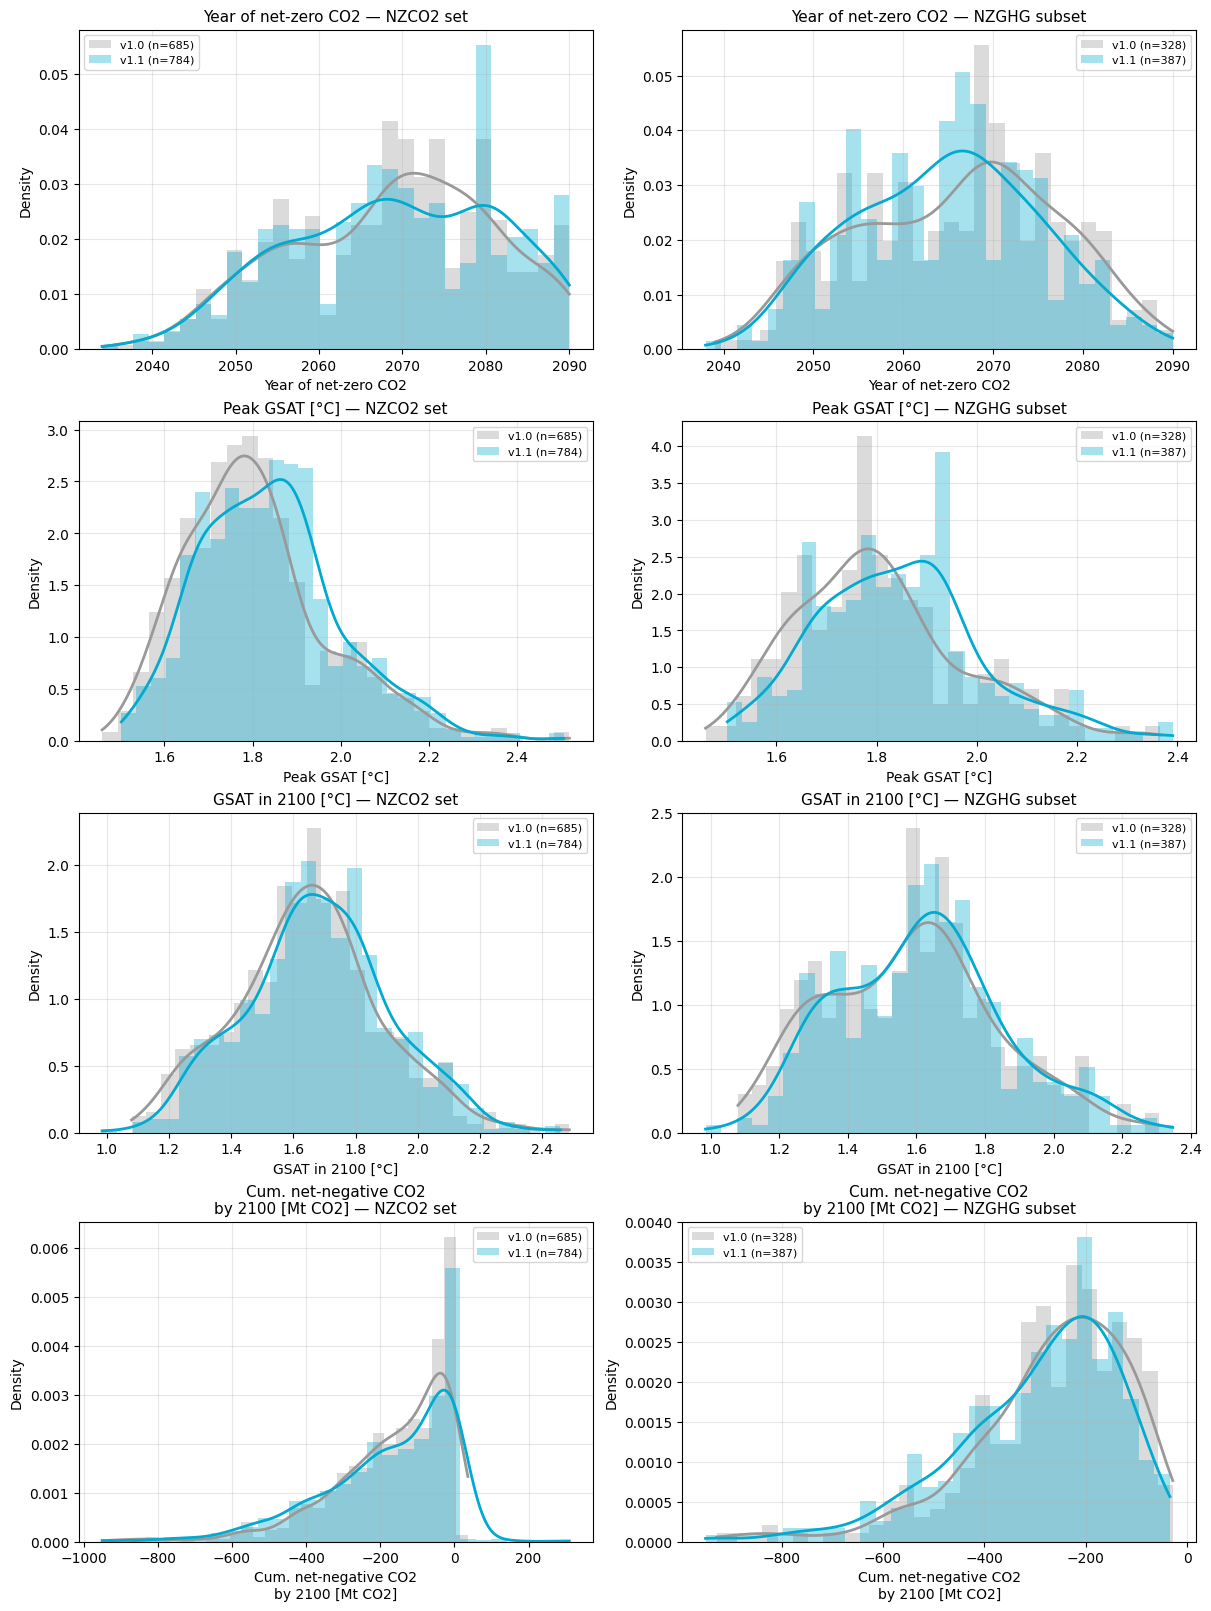

In [27]:
metrics = [
    ("year_netzero_co2", "Year of net-zero CO2"),
    ("gsat_peak", "Peak GSAT [°C]"),
    ("gsat_2100", "GSAT in 2100 [°C]"),
    ("cumulative_netnegative_co2", "Cum. net-negative CO2\nby 2100 [Mt CO2]"),
]

groups = [
    ("NZCO2 set", combined),
    ("NZGHG subset", combined[combined["achieve_netzero_ghg"]]),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16), constrained_layout=True)

for row, (metric_col, metric_label) in enumerate(metrics):
    for col, (group_label, group_df) in enumerate(groups):
        ax = axes[row, col]
        for version in ["v1.0", "v1.1"]:
            data = group_df.loc[group_df["version"] == version, metric_col].dropna()
            if len(data) == 0:
                continue
            ax.hist(data, bins=30, density=True, alpha=0.35, color=VERSION_COLORS[version],
                    label=f"{version} (n={len(data)})")
            if len(data) > 1 and data.nunique() > 1:
                kde = gaussian_kde(data)
                x = np.linspace(data.min(), data.max(), 200)
                ax.plot(x, kde(x), color=VERSION_COLORS[version], linewidth=2)

        ax.set_title(f"{metric_label} \u2014 {group_label}", fontsize=11)
        ax.set_xlabel(metric_label, fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.savefig(PLOT_FOLDER / "901_v1.0_vs_v1.1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Numeric summary

Median and mean per metric/group/version, as a companion to the plots above.

In [17]:
summary_rows = []
for metric_col, metric_label in metrics:
    for group_label, group_df in groups:
        for version in ["v1.0", "v1.1"]:
            data = group_df.loc[group_df["version"] == version, metric_col].dropna()
            summary_rows.append({
                "metric": metric_label,
                "group": group_label,
                "version": version,
                "n": len(data),
                "median": data.median() if len(data) else float("nan"),
                "mean": data.mean() if len(data) else float("nan"),
            })

summary_df = pd.DataFrame(summary_rows)
summary_df

,metric,group,version,n,median,mean
0,Year of net-zero CO2,NZCO2 set,v1.0,685,2070.00000,2068.800000
1,Year of net-zero CO2,NZCO2 set,v1.1,784,2069.00000,2069.085459
2,Year of net-zero CO2,NZGHG subset,v1.0,328,2068.00000,2066.125000
3,Year of net-zero CO2,NZGHG subset,v1.1,387,2065.00000,2064.873385
4,Peak GSAT [°C],NZCO2 set,v1.0,685,1.78300,1.806232
5,Peak GSAT [°C],NZCO2 set,v1.1,784,1.83150,1.840242
6,Peak GSAT [°C],NZGHG subset,v1.0,328,1.78250,1.806184
7,Peak GSAT [°C],NZGHG subset,v1.1,387,1.84050,1.845822
8,GSAT in 2100 [°C],NZCO2 set,v1.0,685,1.65150,1.646891
9,GSAT in 2100 [°C],NZCO2 set,v1.1,784,1.67725,1.680011


## Matched-scenario comparison

The plots above compare the *full* NZCO2/NZGHG sets in each version, which differ in
size (v1.1 has more scenarios overall). To isolate how much of any distributional
shift is due to re-harmonisation/re-infilling *methodology* changes versus simply
having *more scenarios* in v1.1, this section restricts to exactly the `(model,
scenario)` pairs present with GSAT output in **both** versions - i.e. the same
underlying scenarios, run through two different versions of the pipeline.

In [18]:
v10_pairs = set(zip(v10_gsat["model"], v10_gsat["scenario"]))
v11_pairs = set(zip(v11_gsat["model"], v11_gsat["scenario"]))
matched_pairs = v10_pairs & v11_pairs

only_v10 = v10_pairs - v11_pairs
only_v11 = v11_pairs - v10_pairs

print(f"v1.0 scenarios (with GSAT output): {len(v10_pairs)}")
print(f"v1.1 scenarios (with GSAT output): {len(v11_pairs)}")
print(f"Matched (present in both):         {len(matched_pairs)}")
print(f"Only in v1.0 (dropped in v1.1):     {len(only_v10)}")
print(f"Only in v1.1 (new/added):           {len(only_v11)}")

v1.0 scenarios (with GSAT output): 685
v1.1 scenarios (with GSAT output): 784
Matched (present in both):         641
Only in v1.0 (dropped in v1.1):     44
Only in v1.1 (new/added):           143


In [19]:
combined_matched = combined[
    combined.set_index(["model", "scenario"]).index.isin(matched_pairs)
].copy()

print(f"Matched combined: {len(combined_matched)} rows")
combined_matched.groupby("version").size()

Matched combined: 1282 rows


version
v1.0    641
v1.1    641
dtype: int64

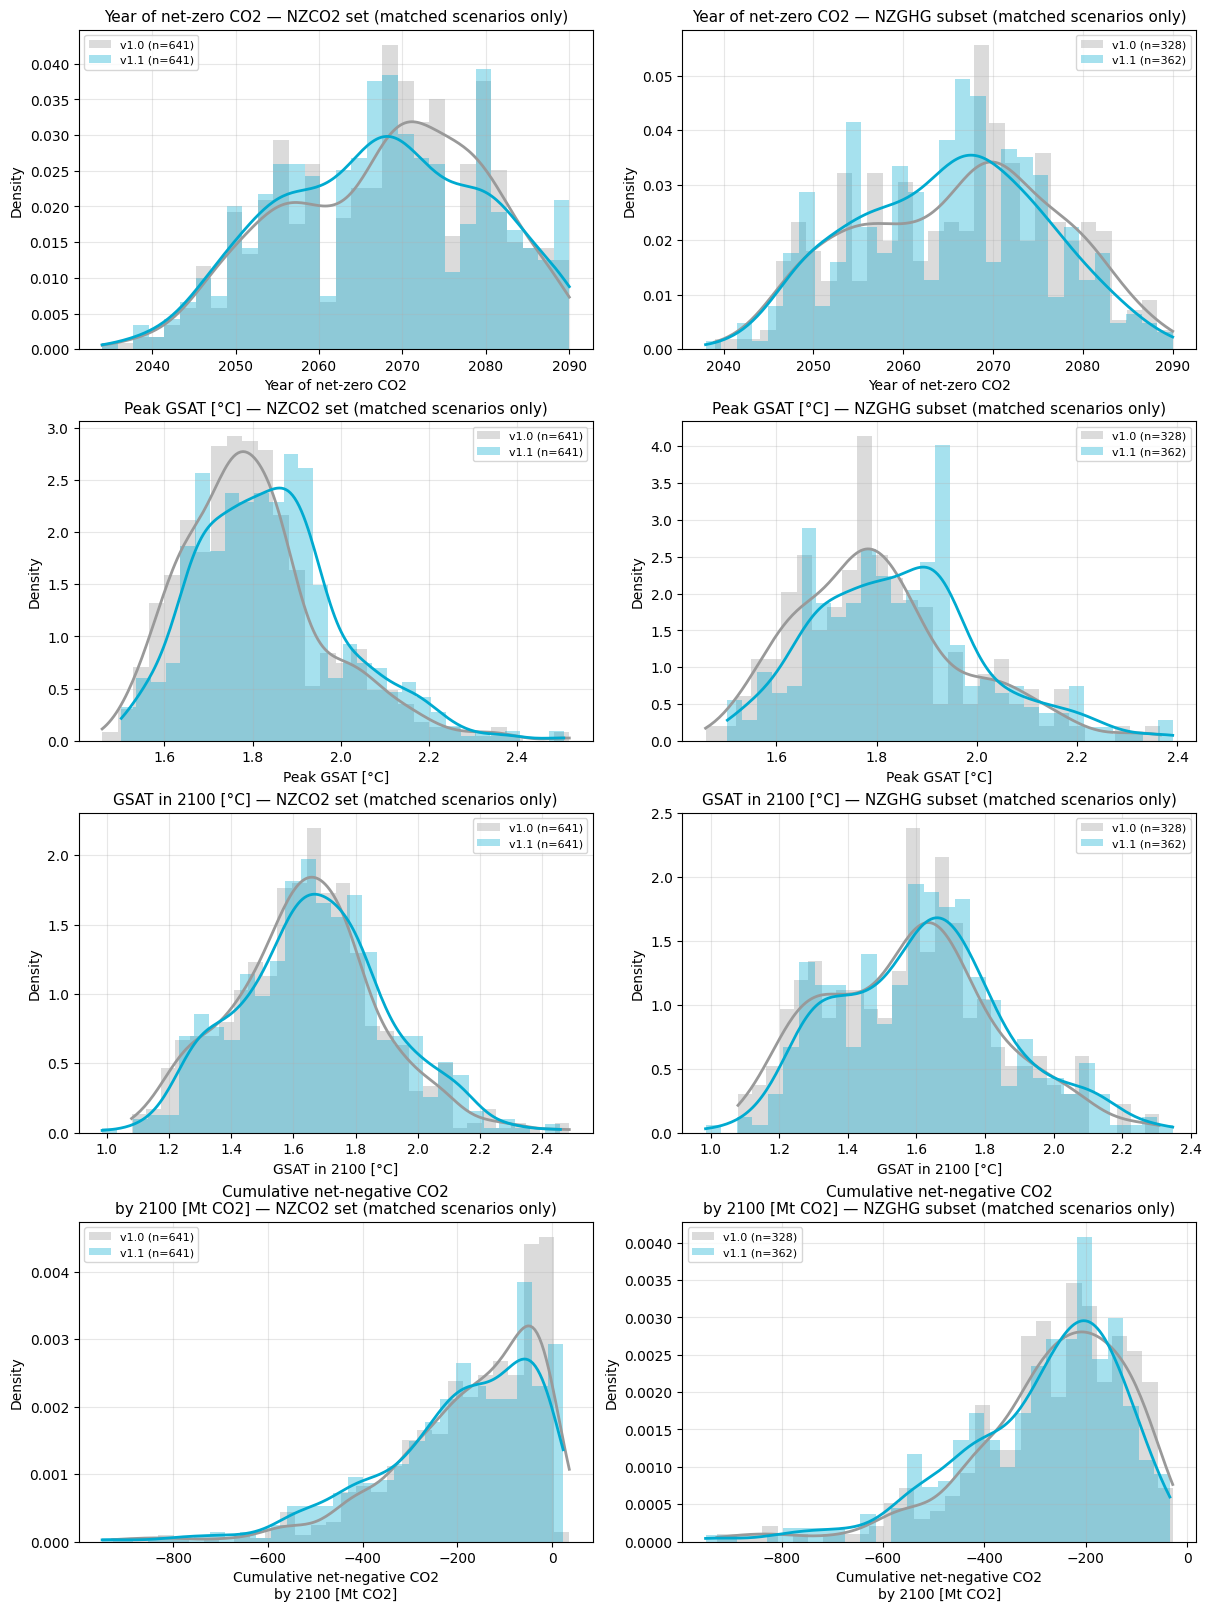

In [20]:
groups_matched = [
    ("NZCO2 set", combined_matched),
    ("NZGHG subset", combined_matched[combined_matched["achieve_netzero_ghg"]]),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16), constrained_layout=True)

for row, (metric_col, metric_label) in enumerate(metrics):
    for col, (group_label, group_df) in enumerate(groups_matched):
        ax = axes[row, col]
        for version in ["v1.0", "v1.1"]:
            data = group_df.loc[group_df["version"] == version, metric_col].dropna()
            if len(data) == 0:
                continue
            ax.hist(data, bins=30, density=True, alpha=0.35, color=VERSION_COLORS[version],
                    label=f"{version} (n={len(data)})")
            if len(data) > 1 and data.nunique() > 1:
                kde = gaussian_kde(data)
                x = np.linspace(data.min(), data.max(), 200)
                ax.plot(x, kde(x), color=VERSION_COLORS[version], linewidth=2)

        ax.set_title(f"{metric_label} \u2014 {group_label} (matched scenarios only)", fontsize=11)
        ax.set_xlabel(metric_label, fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.savefig(PLOT_FOLDER / "901_v1.0_vs_v1.1_comparison_matched.png", dpi=300, bbox_inches="tight")
plt.show()

### Matched-subset numeric summary

Same median/mean comparison as before, restricted to the matched scenario set - the
cleanest read on how much the *same* scenarios shifted purely due to
re-harmonisation/re-infilling and pipeline methodology changes, with the "more
scenarios in v1.1" effect removed.

In [21]:
summary_rows_matched = []
for metric_col, metric_label in metrics:
    for group_label, group_df in groups_matched:
        for version in ["v1.0", "v1.1"]:
            data = group_df.loc[group_df["version"] == version, metric_col].dropna()
            summary_rows_matched.append({
                "metric": metric_label,
                "group": group_label,
                "version": version,
                "n": len(data),
                "median": data.median() if len(data) else float("nan"),
                "mean": data.mean() if len(data) else float("nan"),
            })

summary_df_matched = pd.DataFrame(summary_rows_matched)
summary_df_matched

,metric,group,version,n,median,mean
0,Year of net-zero CO2,NZCO2 set,v1.0,641,2069.00000,2068.032761
1,Year of net-zero CO2,NZCO2 set,v1.1,641,2068.00000,2067.457098
2,Year of net-zero CO2,NZGHG subset,v1.0,328,2068.00000,2066.125000
3,Year of net-zero CO2,NZGHG subset,v1.1,362,2066.00000,2065.102210
4,Peak GSAT [°C],NZCO2 set,v1.0,641,1.78150,1.801371
5,Peak GSAT [°C],NZCO2 set,v1.1,641,1.82900,1.840742
6,Peak GSAT [°C],NZGHG subset,v1.0,328,1.78250,1.806184
7,Peak GSAT [°C],NZGHG subset,v1.1,362,1.83775,1.845631
8,GSAT in 2100 [°C],NZCO2 set,v1.0,641,1.64350,1.636602
9,GSAT in 2100 [°C],NZCO2 set,v1.1,641,1.66050,1.667228


### Summary table with a "new scenarios" column, exported as PNG

Median-only (no mean) comparison across three scenario sets:
- **v1.0** - the 641 matched scenarios, as scored by v1.0
- **v1.1 (matched)** - the same 641 scenarios, as scored by v1.1 (isolates the pure
  methodology effect)
- **v1.1 (new)** - the 143 scenarios newly added in v1.1 with no v1.0 counterpart
  (isolates the pure database-growth effect)

In [22]:
new_only_pairs = only_v11
new_only_df = combined[
    (combined["version"] == "v1.1")
    & combined.set_index(["model", "scenario"]).index.isin(new_only_pairs)
].copy()

print(f"v1.1-only (new) scenarios: {len(new_only_df)}")

sources = {
    "v1.0": combined_matched[combined_matched["version"] == "v1.0"],
    "v1.1 (matched)": combined_matched[combined_matched["version"] == "v1.1"],
    "v1.1 (new)": new_only_df,
}

DELTA_LABEL = "\u0394 (matched \u2212 v1.0)"

group_filters = {
    "NZCO2 set": lambda df: df,
    "NZGHG subset": lambda df: df[df["achieve_netzero_ghg"]],
}

col_order = []
for g in group_filters:
    col_order.append((g, "v1.0"))
    col_order.append((g, "v1.1 (matched)"))
    col_order.append((g, DELTA_LABEL))
    col_order.append((g, "v1.1 (new)"))

n_lookup = {
    (g, s): (len(group_filters[g](sources[s])) if s in sources else None)
    for g, s in col_order
}
n_lookup

v1.1-only (new) scenarios: 143


{('NZCO2 set', 'v1.0'): 641,
 ('NZCO2 set', 'v1.1 (matched)'): 641,
 ('NZCO2 set', 'Δ (matched − v1.0)'): None,
 ('NZCO2 set', 'v1.1 (new)'): 143,
 ('NZGHG subset', 'v1.0'): 328,
 ('NZGHG subset', 'v1.1 (matched)'): 362,
 ('NZGHG subset', 'Δ (matched − v1.0)'): None,
 ('NZGHG subset', 'v1.1 (new)'): 25}

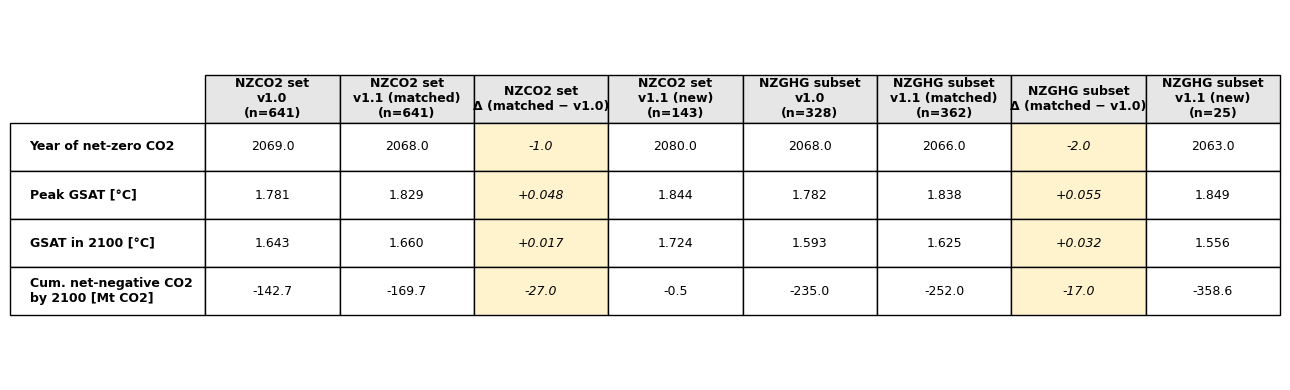

In [29]:
decimals = {
    "Year of net-zero CO2": 1,
    "Peak GSAT [°C]": 3,
    "GSAT in 2100 [°C]": 3,
    "Cum. net-negative CO2\nby 2100 [Mt CO2]": 1,
}

row_labels = [label for _, label in metrics]
col_labels = [
    f"{g}\n{s}" if s == DELTA_LABEL else f"{g}\n{s}\n(n={n_lookup[(g, s)]})"
    for g, s in col_order
]

cell_text = []
for metric_col, metric_label in metrics:
    row = []
    for g, s in col_order:
        ndigits = decimals[metric_label]
        if s == DELTA_LABEL:
            v10_val = group_filters[g](sources["v1.0"])[metric_col].median()
            v11_val = group_filters[g](sources["v1.1 (matched)"])[metric_col].median()
            if pd.isna(v10_val) or pd.isna(v11_val):
                row.append("n/a")
            else:
                delta = v11_val - v10_val
                row.append(f"{delta:+.{ndigits}f}")
            continue
        sub = group_filters[g](sources[s])
        val = sub[metric_col].median()
        if pd.isna(val) or len(sub) == 0:
            row.append("n/a")
        else:
            row.append(f"{val:.{ndigits}f}")
    cell_text.append(row)

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")
table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                  cellLoc="center", rowLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.4)
delta_cols = {c for c, (_, s) in enumerate(col_order) if s == DELTA_LABEL}
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#e6e6e6")
    if c == -1:
        cell.set_text_props(weight="bold", ha="left")
    if c in delta_cols and r > 0:
        cell.set_facecolor("#fff3cd")
        cell.set_text_props(style="italic")

fig.tight_layout()
fig.savefig(PLOT_FOLDER / "901_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()